# Puzzle Velocity Analysis

A calibration analysis of `docs/puzzle-velocity.csv` — the per-ticket time log for the
lccjs Yegor-style microtask workflow (dual **H**ard-cap / **C**alibrated estimates vs
actuals), enriched by `stats/enrich.py` with git churn, GitHub issue timestamps, and
notes-parsed flags.

## ⚠️ Read this before trusting any number

This dataset is **small and shallow**, and the analysis below is deliberately
conservative about what it claims:

- **n = 36** rows with a C estimate, all from a **single ~9-hour session** (not a
  multi-day track record). There is therefore **no real "over time" axis** — anything
  that looks like a trend is confounded with within-session context-warming, fatigue,
  and the order tasks happened to be picked.
- **Actuals are self-reported and tiny.** Median `actual_min` ≈ 3 min; ~1/3 of rows are
  under 2 minutes. The measurement noise floor (~±1 min) is a large fraction of the
  signal, so **ratios of these numbers are inherently unstable** — a task logged as 1.4
  vs 2.8 min flips its ratio 2× on essentially nothing.
- **The flags are self-authored.** `f_test_loop` / `f_overrun` etc. are regex-scraped
  from the same free-text notes written by the estimator being graded — hypothesis and
  evidence share a pen. Two rows (#150, #146) set their C estimate *after* the actual was
  known (`f_retro_c`); those are **excluded** from every calibration metric below.

**Bottom line up front:** exactly **two** findings survive scrutiny — (1) the estimator
is *directionally* biased high, robustly; (2) lines-of-code is *uncorrelated* with effort.
Everything about *magnitude*, *per-role* differences, *over-time* improvement, and the
*test-loop overrun mechanism* is **underpowered and reported as a hypothesis, not a
result** (§6).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

rng = np.random.default_rng(0)  # fixed seed -> reproducible bootstrap
plt.rcParams.update({"figure.figsize": (11, 5), "axes.grid": True, "grid.alpha": 0.3})

csv_path = next((p for p in [Path("puzzle-velocity-enriched.csv"),
                             Path("stats/puzzle-velocity-enriched.csv")] if p.exists()), None)
assert csv_path, "Run `python3 stats/enrich.py` first."
df = pd.read_csv(csv_path)

for c in ["issue_created", "issue_closed", "commit_date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)
df = df.sort_values("issue_closed", kind="stable").reset_index(drop=True)
df["seq"] = range(1, len(df) + 1)

# Boolean coercion (enrich.py writes the strings "true"/"false").
for c in ["cross_repo", "f_worktree", "f_overrun", "f_test_loop", "f_retro_c", "f_crossrepo_note"]:
    df[c] = df[c].astype(str).str.lower().eq("true")

# The calibration set: rows with a C estimate that was a genuine *prediction*
# (drop the post-hoc / retro-set estimates — they cannot test forecasting).
hc = df[df["c_min"].notna()].copy()
cal = hc[~hc["f_retro_c"]].copy()
cal["ratio"] = cal["c_min"] / cal["actual_min"]      # >1 = over-padded
cal["log_ratio"] = np.log(cal["ratio"])              # symmetric, additive

print(f"all rows: {len(df)}  |  with C estimate: {len(hc)}  |  "
      f"calibration set (excl. retro-C): {len(cal)}  (dropped {hc['f_retro_c'].sum()})")


all rows: 41  |  with C estimate: 36  |  calibration set (excl. retro-C): 34  (dropped 2)


## 0. Data provenance & noise floor

Before any conclusion, here is exactly how thin the data is. Every later section is
gated against these counts.

In [2]:
span = df["issue_closed"].max() - df["issue_closed"].min()
print("DATASET SCOPE")
print(f"  rows total ................. {len(df)}")
print(f"  with C estimate ............ {len(hc)}")
print(f"  calibration set ............ {len(cal)}  (excl. {hc['f_retro_c'].sum()} retro-C: "
      f"{hc.loc[hc['f_retro_c'],'ticket'].tolist()})")
print(f"  wall-clock span of ALL data  {span}  <- single session")
print()
print("NOISE FLOOR (why ratios are shaky)")
print(f"  median actual_min .......... {cal['actual_min'].median():.2f} min")
print(f"  rows under 2 min ........... {(cal['actual_min'] < 2).sum()} / {len(cal)}")
print(f"  rows under 5 min ........... {(cal['actual_min'] < 5).sum()} / {len(cal)}")
print()
print("POWER PER ROLE (used to gate §6)")
gate = cal.groupby("role").agg(n=("ticket", "size")).assign(
    evaluable=lambda d: np.where(d["n"] >= 5, "yes", "NO (n<5)"))
print(gate.to_string())


DATASET SCOPE
  rows total ................. 41
  with C estimate ............ 36
  calibration set ............ 34  (excl. 2 retro-C: [150, 146])
  wall-clock span of ALL data  0 days 09:04:02  <- single session

NOISE FLOOR (why ratios are shaky)
  median actual_min .......... 2.84 min
  rows under 2 min ........... 11 / 34
  rows under 5 min ........... 24 / 34

POWER PER ROLE (used to gate §6)
         n evaluable
role                
ARC      4  NO (n<5)
DEV     16       yes
TEST     1  NO (n<5)
WRITER  13       yes


## 1. The one robust finding — the estimator is biased high

Forget the magnitude for a moment. The *direction* is unambiguous: almost every task
finished faster than its calibrated estimate. With binary over/under outcomes this is a
sign test, which makes no assumption about the (noisy) ratio sizes.

In [3]:
n = len(cal)
n_over = int((cal["ratio"] > 1).sum())
bt = stats.binomtest(n_over, n, 0.5, alternative="greater")
ci = bt.proportion_ci(confidence_level=0.95)
print(f"over-padded (finished faster than C): {n_over}/{n} = {n_over/n:.0%}")
print(f"sign test vs 50/50: p = {bt.pvalue:.2e}")
print(f"95% CI on the over-pad fraction: [{ci.low:.0%}, {ci.high:.0%}]")
print(f"the {n - n_over} exceptions (overruns): {cal.loc[cal['ratio'] <= 1, 'ticket'].tolist()}")


over-padded (finished faster than C): 32/34 = 94%
sign test vs 50/50: p = 3.47e-08
95% CI on the over-pad fraction: [83%, 100%]
the 2 exceptions (overruns): [135, 141]


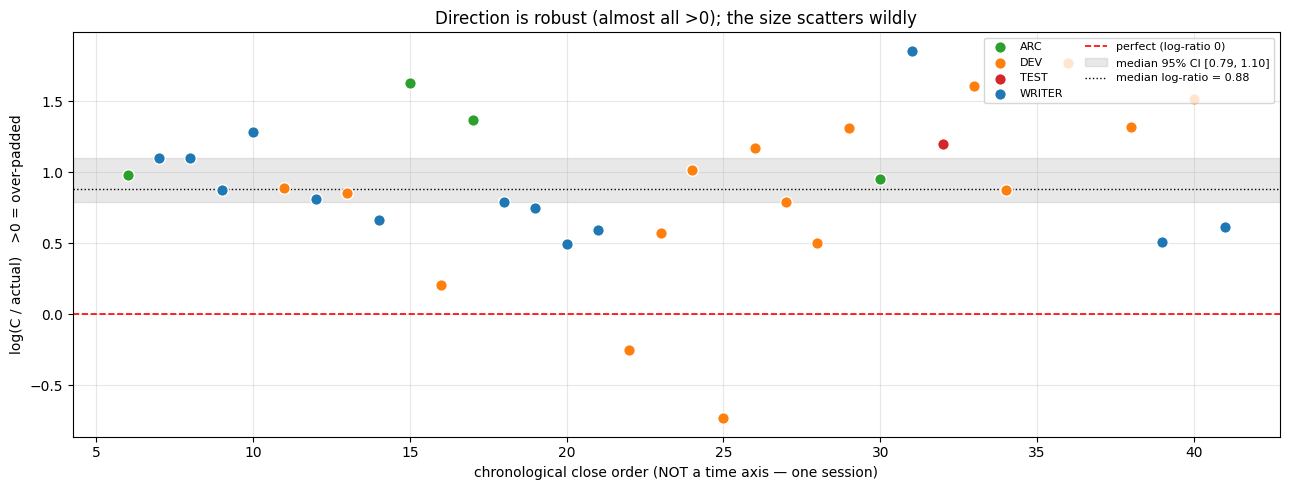

In [4]:
# Per-ticket log-ratio with a bootstrapped CI band on the median.
boot = np.array([np.median(rng.choice(cal["log_ratio"].values, size=n, replace=True))
                 for _ in range(5000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
med = cal["log_ratio"].median()

fig, ax = plt.subplots(figsize=(13, 5))
colors = {"WRITER": "#1f77b4", "DEV": "#ff7f0e", "ARC": "#2ca02c", "TEST": "#d62728"}
for role, g in cal.groupby("role"):
    ax.scatter(g["seq"], g["log_ratio"], s=70, label=role,
               color=colors.get(role, "#888"), edgecolor="white", zorder=3)
ax.axhline(0, ls="--", color="red", lw=1.2, label="perfect (log-ratio 0)")
ax.axhspan(lo, hi, color="grey", alpha=0.18, label=f"median 95% CI [{lo:.2f}, {hi:.2f}]")
ax.axhline(med, ls=":", color="black", lw=1, label=f"median log-ratio = {med:.2f}")
ax.set(xlabel="chronological close order (NOT a time axis — one session)",
       ylabel="log(C / actual)   >0 = over-padded",
       title="Direction is robust (almost all >0); the size scatters wildly")
ax.legend(loc="upper right", ncol=2, fontsize=8)
plt.tight_layout(); plt.show()


**Read:** the cloud sits clearly above the red `0` line — the estimator over-pads
in the large majority of cases, and the bootstrap CI for the median log-ratio excludes 0.
That bias is the trustworthy headline. Note how *vertically spread* the points are: the
**magnitude** of over-padding is not a stable quantity (next section).

## 2. How big is the bias — honestly, with a confidence interval

The mean C-ratio (~3.0x) is **outlier-driven and misleading** — it's an average of
ratios with tiny, noisy denominators, dominated by a few extreme rows. Report the median
with a bootstrap CI, and look at the *distribution*, not a single number.

median C-ratio ........ 2.41x   95% CI [2.20, 3.00]
mean   C-ratio ........ 2.81x   <- DISTORTED:
  top-3 rows ([147, 149, 115] = [6.4, 5.9, 5.1]x) are 18% of the summed ratio

Implied naive correction: multiply a gut C estimate by ~0.41 (= 1 / 2.41).
  ^ IN-SAMPLE only. This has not been validated on held-out puzzles (see §7).


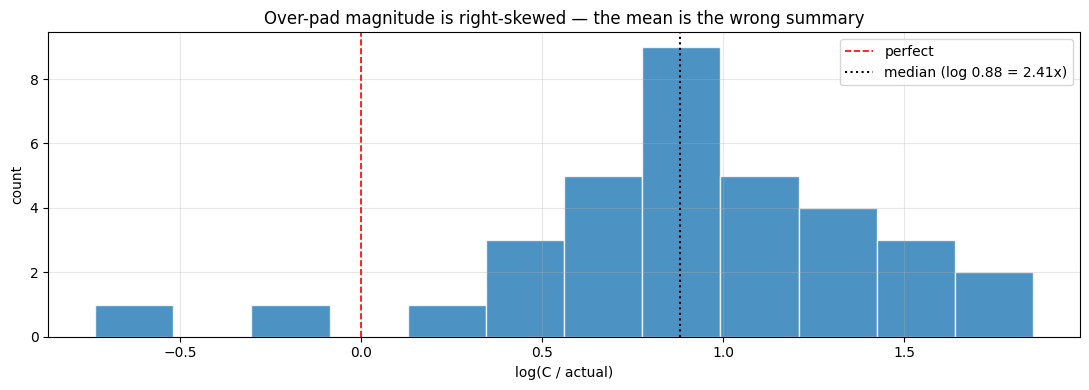

In [5]:
ratio_boot = np.array([np.median(rng.choice(cal["ratio"].values, size=n, replace=True))
                        for _ in range(5000)])
rlo, rhi = np.percentile(ratio_boot, [2.5, 97.5])
top3 = cal["ratio"].nlargest(3)
print(f"median C-ratio ........ {cal['ratio'].median():.2f}x   95% CI [{rlo:.2f}, {rhi:.2f}]")
print(f"mean   C-ratio ........ {cal['ratio'].mean():.2f}x   <- DISTORTED:")
print(f"  top-3 rows ({top3.index.map(lambda i: int(cal.loc[i,'ticket'])).tolist()} "
      f"= {top3.round(1).tolist()}x) are {top3.sum()/cal['ratio'].sum():.0%} of the summed ratio")
print(f"\nImplied naive correction: multiply a gut C estimate by ~{1/cal['ratio'].median():.2f} "
      f"(= 1 / {cal['ratio'].median():.2f}).")
print("  ^ IN-SAMPLE only. This has not been validated on held-out puzzles (see §7).")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(cal["log_ratio"], bins=12, color="#1f77b4", alpha=0.8, edgecolor="white")
ax.axvline(0, ls="--", color="red", lw=1.2, label="perfect")
ax.axvline(med, ls=":", color="black", label=f"median (log {med:.2f} = {np.exp(med):.2f}x)")
ax.set(xlabel="log(C / actual)", ylabel="count",
       title="Over-pad magnitude is right-skewed — the mean is the wrong summary")
ax.legend(); plt.tight_layout(); plt.show()


## 3. Calibration plot — predicted vs actual

The honest way to show both bias *and* spread: plot the prediction (`c_min`) against the
outcome (`actual_min`). Points above the `y = x` line are over-estimates. The fitted line
(log-log) summarises the systematic component; the scatter around it is the irreducible
noise you'd carry into any future estimate.

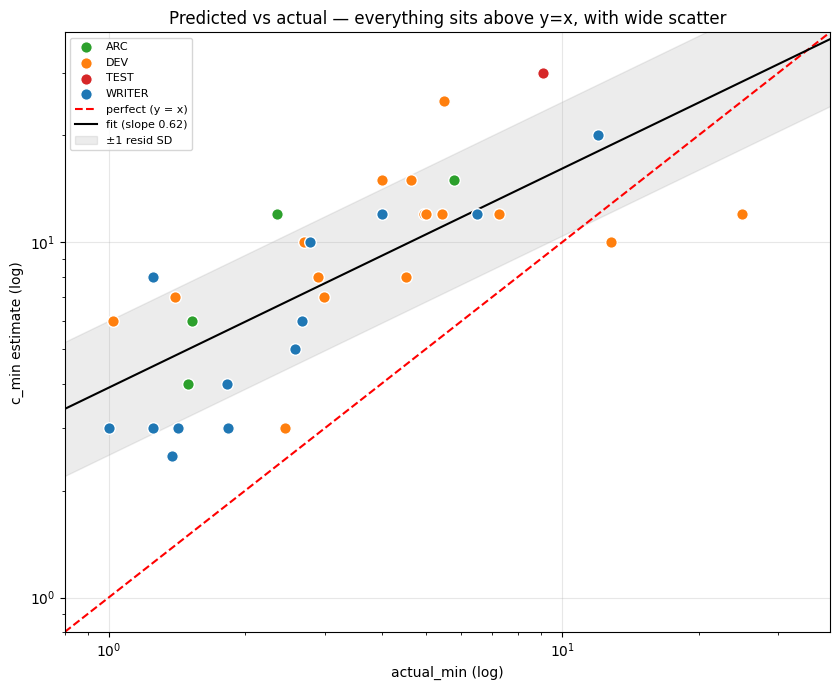

log-log fit slope = 0.62 (1.0 would mean a constant multiplier); residual SD = 0.43 in log space (~1.54x typical miss)


In [6]:
x = np.log(cal["actual_min"]); y = np.log(cal["c_min"])
sl, ic_, r, p, se = stats.linregress(x, y)
resid_sd = np.std(y - (sl * x + ic_))

fig, ax = plt.subplots(figsize=(8.5, 7))
for role, g in cal.groupby("role"):
    ax.scatter(g["actual_min"], g["c_min"], s=70, label=role,
               color=colors.get(role, "#888"), edgecolor="white", zorder=3)
lims = [0.8, max(cal["actual_min"].max(), cal["c_min"].max()) * 1.3]
ax.plot(lims, lims, ls="--", color="red", label="perfect (y = x)")
xs = np.linspace(np.log(lims[0]), np.log(lims[1]), 50)
ax.plot(np.exp(xs), np.exp(sl * xs + ic_), color="black", lw=1.5,
        label=f"fit (slope {sl:.2f})")
ax.fill_between(np.exp(xs), np.exp(sl * xs + ic_ - resid_sd), np.exp(sl * xs + ic_ + resid_sd),
                color="grey", alpha=0.15, label="±1 resid SD")
ax.set(xscale="log", yscale="log", xlabel="actual_min (log)", ylabel="c_min estimate (log)",
       xlim=lims, ylim=lims,
       title="Predicted vs actual — everything sits above y=x, with wide scatter")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"log-log fit slope = {sl:.2f} (1.0 would mean a constant multiplier); "
      f"residual SD = {resid_sd:.2f} in log space (~{np.exp(resid_sd):.2f}x typical miss)")


**Read:** every point is above `y = x` (the bias again), but the band is wide — even
*with* a fitted correction, a typical estimate would still be off by roughly the residual
factor shown. A slope below 1 hints the over-padding is proportionally worse for the
smallest tasks, but with this n that's suggestive, not established.

## 4. Lines-of-code is uncorrelated with effort (a clean null result)

The "LOC could signal drift" idea, tested directly. Cross-repo rows (no local churn) are
excluded.

LOC ~ actual_min  Pearson r = -0.114   Spearman = -0.012   (n=28)
  without top-10% LOC rows: Pearson r = -0.136 (n=25)
  => effectively ZERO, and robust to outliers.


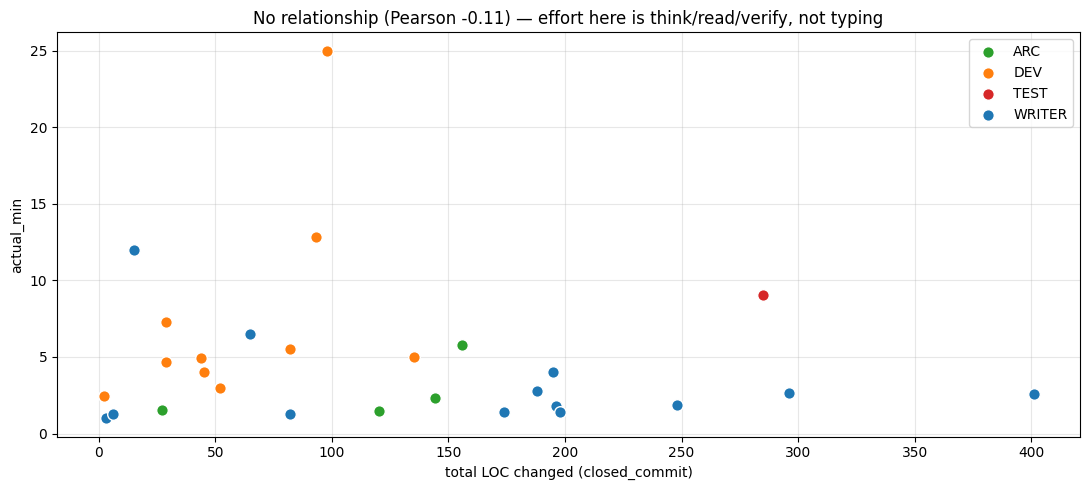

In [7]:
ir = cal[~cal["cross_repo"]].dropna(subset=["total_loc"])
pear = ir["total_loc"].corr(ir["actual_min"])
spear = ir["total_loc"].corr(ir["actual_min"], method="spearman")
ir_trim = ir[ir["total_loc"] < ir["total_loc"].quantile(0.9)]
print(f"LOC ~ actual_min  Pearson r = {pear:+.3f}   Spearman = {spear:+.3f}   (n={len(ir)})")
print(f"  without top-10% LOC rows: Pearson r = {ir_trim['total_loc'].corr(ir_trim['actual_min']):+.3f} (n={len(ir_trim)})")
print("  => effectively ZERO, and robust to outliers.")

fig, ax = plt.subplots()
for role, g in ir.groupby("role"):
    ax.scatter(g["total_loc"], g["actual_min"], s=70, label=role,
               color=colors.get(role, "#888"), edgecolor="white", zorder=3)
ax.set(xlabel="total LOC changed (closed_commit)", ylabel="actual_min",
       title=f"No relationship (Pearson {pear:+.2f}) — effort here is think/read/verify, not typing")
ax.legend(); plt.tight_layout(); plt.show()


**Read:** a genuine null. Time is dominated by reading/verifying, not code volume — a
400-LOC mechanical glossary write can be faster than a 90-LOC investigation. **Do not use
LOC as an effort proxy.** (Whether LOC works as a *drift* signal is a different, untested
question — see §7; it is not claimed here.)

## 5. Lead time is bimodal — don't average it

`lead_min` (issue created → work started) is not one population. It's two: just-in-time
PDD puzzles filed *as* work begins, and genuine backlog items filed earlier. A single
median lands in the empty gap between them and means nothing.

lead_min: n=36  | negatives (clock skew, treated separately): 2
  just-in-time (0–5 min): 7   |   backlog (>=5 min): 27
  reporting one median (35 min) across this mixture is misleading.


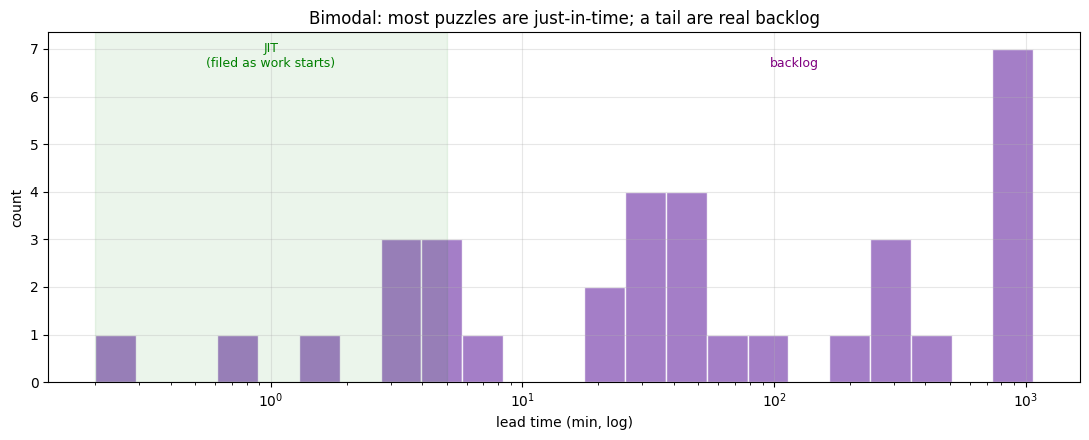

In [8]:
lm = pd.to_numeric(df["lead_min"], errors="coerce").dropna()
neg = (lm < 0).sum()
jit = lm[(lm >= 0) & (lm < 5)]
back = lm[lm >= 5]
print(f"lead_min: n={len(lm)}  | negatives (clock skew, treated separately): {neg}")
print(f"  just-in-time (0–5 min): {len(jit)}   |   backlog (>=5 min): {len(back)}")
print(f"  reporting one median ({lm.median():.0f} min) across this mixture is misleading.")

fig, ax = plt.subplots(figsize=(11, 4.5))
bins = np.logspace(np.log10(0.2), np.log10(max(lm.max(), 2)), 24)
ax.hist(lm[lm > 0], bins=bins, color="#9467bd", alpha=0.85, edgecolor="white")
ax.axvspan(0.2, 5, color="green", alpha=0.08)
ax.text(1, ax.get_ylim()[1]*0.9, "JIT\n(filed as work starts)", ha="center", fontsize=9, color="green")
ax.text(120, ax.get_ylim()[1]*0.9, "backlog", ha="center", fontsize=9, color="purple")
ax.set(xscale="log", xlabel="lead time (min, log)", ylabel="count",
       title="Bimodal: most puzzles are just-in-time; a tail are real backlog")
plt.tight_layout(); plt.show()


## 6. Underpowered — reported as hypotheses, NOT results

These are the questions the notes speculate about. With this data they **cannot be
answered**. Shown for transparency, explicitly flagged as not evaluated.

In [9]:
print("(a) PER-ROLE differences")
for r, g in cal.groupby("role"):
    verdict = "" if len(g) >= 5 else "   <-- n<5, NOT EVALUATED"
    print(f"    {r:6} n={len(g):2d}  median ratio={g['ratio'].median():.2f}x"
          f"  range=[{g['ratio'].min():.2f}, {g['ratio'].max():.2f}]{verdict}")
print("    TEST has n=1 (a single point) — any 'role effect' is noise. ARC's range is")
print("    driven entirely by one row (#146). Treat role differences as UNTESTED.\n")

print("(b) 'TEST-LOOP tasks overrun' hypothesis")
tl = cal[cal["f_test_loop"]]
print(f"    test-loop rows: n={len(tl)}  ratios={tl['ratio'].round(2).tolist()}  -> a coin flip, n=2")
ov = cal[cal["ratio"] <= 1][["ticket", "role", "f_test_loop", "f_overrun"]]
print(f"    the 2 overruns:\n{ov.to_string(index=False)}")
print("    NOTE: only #135 is a test loop; #141 overran from a mid-task redesign, NOT a")
print("    loop. The earlier 'both are test-loop tasks' claim was wrong. n=2 regardless.\n")

print("(c) 'Calibration improves over time'")
print(f"    ALL {len(df)} rows span one ~9h session. There is no multi-day axis to detect")
print("    learning on; cumulative-mean 'convergence' is an artifact of averaging. NOT EVALUATED.")


(a) PER-ROLE differences
    ARC    n= 4  median ratio=3.29x  range=[2.60, 5.11]   <-- n<5, NOT EVALUATED
    DEV    n=16  median ratio=2.41x  range=[0.48, 5.88]
    TEST   n= 1  median ratio=3.31x  range=[3.31, 3.31]   <-- n<5, NOT EVALUATED
    WRITER n=13  median ratio=2.20x  range=[1.64, 6.40]
    TEST has n=1 (a single point) — any 'role effect' is noise. ARC's range is
    driven entirely by one row (#146). Treat role differences as UNTESTED.

(b) 'TEST-LOOP tasks overrun' hypothesis
    test-loop rows: n=2  ratios=[0.78, 1.77]  -> a coin flip, n=2
    the 2 overruns:
 ticket role  f_test_loop  f_overrun
    135  DEV         True       True
    141  DEV        False       True
    NOTE: only #135 is a test loop; #141 overran from a mid-task redesign, NOT a
    loop. The earlier 'both are test-loop tasks' claim was wrong. n=2 regardless.

(c) 'Calibration improves over time'
    ALL 41 rows span one ~9h session. There is no multi-day axis to detect
    learning on; cumulative-mean

## 7. Takeaways

**Trust:**
- The estimator is **biased high** — 32/34 calibration tasks finished faster than the C
  estimate (sign test p ≈ 1e-7, CI on the over-pad fraction well above 50%). This is the
  one solid, actionable result: **C estimates are systematically too high.**
- **LOC is uncorrelated with effort** (Pearson ≈ 0, robust). Don't estimate from code size.

**Don't trust (yet):**
- The "~2.5x" / "3x" *magnitude* — unstable (tiny noisy denominators), right-skewed, wide CI.
- Any **per-role** ranking (TEST n=1; ARC driven by one row).
- The **test-loop overrun** mechanism (n=2, and half-wrong on attribution).
- Any **over-time / improving-calibration** claim (single session).

**The actionable move:** apply a *rough* downward correction to C estimates (start around
÷2–2.5), then **validate it prospectively** — that is the real job of follow-up #174.

---

## How to improve / extend this analysis further

- **Turn it into a prospective backtest (highest leverage).** Freeze one correction rule
  now, then on the *next* N puzzles record the prediction *before* the work and score it
  out-of-sample. In-sample over-pad is description; a held-out hit-rate is a model. This
  is what #174 should be.
- **Collect across multiple days/sessions.** Only then does an "over time" axis exist and
  "is calibration improving?" become answerable (with a proper trend test on log-ratio vs
  calendar time — not an expanding mean).
- **Raise the measurement floor.** Sub-3-minute self-timed actuals can't support
  2-significant-figure ratios. Log coarser buckets, or longer tasks, or capture start/stop
  timestamps programmatically to shrink the noise.
- **Gate every cut on power.** Keep the n≥5 rule; never plot a single-point "distribution."
  Add bootstrap CIs or sign-test CIs to every summary number.
- **Keep retro-set estimates quarantined**, and ideally stop creating them — record the C
  *before* starting so it's a genuine prediction.
- **De-circularise the flags.** `f_test_loop` / `f_overrun` are scraped from the
  estimator's own notes. Capture task attributes independently (e.g. a structured field at
  grab time) so the hypothesis and the evidence don't share an author.
- **Add prediction intervals to the calibration plot** and, once n per role clears the
  gate, fit per-role corrections with intervals rather than point multipliers.
- **Test LOC (and other git signals) as a *drift* metric explicitly** — define drift
  operationally (e.g. residual of actual vs model prediction) and regress it on candidate
  signals, instead of asserting LOC "detects drift."
- **Render lead time as the two labelled modes** (done here) and track JIT-vs-backlog mix
  over time as a workflow-health metric, rather than a meaningless central tendency.
- **Wire the deferred enrichments** from `stats/README.md` (multi-commit churn for
  multi-pass tickets, prose-vs-code churn split, blame age, idle/compaction from
  span − actual) — but only adopt each once it earns its place against a real question.
